### Build A Basic Chatbot With Langraph(GRAPH API)

In [1]:
 from typing import Annotated
 from typing_extensions import TypedDict
 from langgraph.graph import StateGraph,START,END
 from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "List", The "add_messages" function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder=StateGraph(State)    

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="qwen/qwen3.6-27b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x000002734E857470>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002734E9BB710>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
llm = init_chat_model(
    model="qwen/qwen3.6-27b",
    model_provider="groq",
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x000002734E9D8890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002734E9D8DA0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [9]:
graph_builder = StateGraph(State)

# Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()


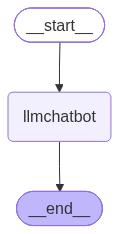

In [10]:
## visulaize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass    



In [11]:
response=graph.invoke({"messages":"Hi"})

In [12]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a simple greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Offer assistance\n   - Keep it open-ended to encourage the user to share what they need\n4.  **Draft Response (Mental):** "Hello! How can I help you today?" or "Hi there! What\'s on your mind?" \n5.  **Refine Response:** Keep it friendly, professional, and concise. Match the tone of the greeting.\n6.  **Final Output Generation:** "Hello! How can I assist you today?" (or similar)✅\n</think>\n\nHello! How can I help you today? 😊'

In [13]:
from langchain_core.messages import HumanMessage

for event in graph.stream(
    {"messages": [HumanMessage(content="Hi, How are you?")]}
):
    for value in event.values():
        last_message = value["messages"][-1]
        print(last_message.content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "Hi, How are you?"
   - This is a standard greeting and a polite inquiry about my state/well-being.

2.  **Identify Key Components:**
   - Greeting: "Hi"
   - Question: "How are you?"
   - Tone: Friendly, casual

3.  **Determine Response Strategy:**
   - Acknowledge the greeting
   - Respond to the question politely
   - Keep it concise and friendly
   - Offer assistance (standard AI behavior)
   - Maintain appropriate tone (warm, helpful)

4.  **Draft Response (Mental):**
   Hi! I'm doing well, thank you for asking. How are you doing? Is there anything I can help you with today?

5.  **Refine Response:**
   - Check tone: Friendly and professional
   - Check accuracy: I'm an AI, so "doing well" is fine as a polite convention
   - Check structure: Greeting + response + return question + offer help
   - Matches standard AI response patterns

   Final version: "Hi! I'm doing well, thank you for asking. How ar

### ChatBot With Tools

In [15]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API [...] ## Building a Simple Chatbot with LangGraph\n\nLangGraph makes it easy to build structured, stateful applications like chatbots. In this example we’ll learn how

In [16]:
## custom function
def multiply(a:int,b:int)->int:
    """
    Multiplies two integers and returns the result.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.
        
    Returns:
        int: The product of the two integers.
    """
    return a * b

In [17]:
tools=[tool,multiply]

In [19]:
llm_with_tool=llm.bind_tools(tools)

In [21]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x000002734E9D8890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002734E9D8DA0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'str

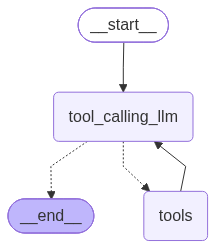

In [24]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Adding Edges
builder.add_edge(START,"tool_calling_llm")
# If the latest message (result) from assistant is a tool call -> tools_condition route to tools
# If the latest message (result) from assistant is not a tool call -> tools_condition route to END
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [26]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [27]:
response["messages"][-1].content

'Recent developments in the artificial intelligence landscape cover a range of major corporate shifts, hardware competition, and new regulations:\n\n**1. Industry Acquisitions and Investments**\n*   **Dynatrace and Arize:** Dynatrace has signed a definitive agreement to acquire AI observability company Arize in a deal valued at approximately $915 million. This move aims to combine AI-native evaluation and experimentation with enterprise observability.\n*   **SpaceX and AI Coding:** In a series of aggressive moves, SpaceX recently acquired the AI coding tool Cursor for $60 billion. Shortly after, reports emerged that the company attempted to acquire the AI startup Cognition.\n*   **Funding:** A British AI-chip startup has reportedly raised significant capital (at a $6.5 billion valuation) following a partnership deal with Anthropic.\n\n**2. Hardware and Chip Competition**\n*   **Rivalry with Nvidia:** Prompted by Nvidia’s market dominance, a group of major tech companies—including Intel